In [1]:
import jax.numpy as jnp
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import euclidean_distances
from sklearn.decomposition import PCA
from tqdm import tqdm
from scipy.stats import spearmanr, pearsonr

from cmonge.datasets.conditional_loader import ConditionalDataModule
from cmonge.utils import load_config
from cmonge.metrics import wasserstein_distance

# Preprocessing/formatting of embeddings and smiles - only done once

In [2]:
# smiles = pd.read_csv("/Users/adr/Box/otperturb/datasets/4i/drugs.smiles", delimiter="\t").rename(columns={"Name": "drug", "SMILES": "smiles"})
# smiles

In [3]:
# read_dir = "/Users/adr/Downloads/4i_embeddings/"
# save_dir = "/Users/adr/Box/otperturb/alice_exp/models/embed/4i/"
# all_embeddings = ["molformer_xl", "morganfp", "text-embedding-004", "textchemt5", "toxsmi"]

In [4]:
# # Npy to pandas dataframe to be in same format as MoA embedding
# for embedding in all_embeddings:
#     embed = pd.DataFrame(np.load(f"{read_dir}{embedding}.npy"))
#     embed.index=smiles["drug"]
#     embed.index = embed.index.rename(None)
#     embed = embed.T
#     embed.to_csv(f"{save_dir}{embedding}")

### Smiles for RDkit embedding calculation

In [5]:
# smiles["smiles"].to_csv("/Users/adr/Box/otperturb/benedek-archive/ot-perturb/data/4i_drugs.smiles", index=False)

In [6]:
# smiles.rename(columns={"smiles": "smile"}).to_csv("/Users/adr/Box/otperturb/benedek-archive/ot-perturb/data/4i_drug_smiles.csv")

In [7]:
# smiles["drug"].values

# Embedding evaluation

In [8]:
non_data_drugs = ["carfilzomib", "pomalidomide", "cobimetinib", "vemurafenib"]

In [9]:
smiles = pd.read_csv("/Users/adr/Box/otperturb/datasets/4i/drugs.smiles", delimiter="\t")

In [10]:
config_path = "/Users/adr/Projects/enlight/enlight/OT_analysis/condmonge/configs/4i/conditional-monge-4i.yml"

In [11]:
config = load_config(config_path)
config.data.file_path = "/Users/adr/Box/otperturb/datasets/4i/8h.h5ad"
config.data.features = "/Users/adr/Box/otperturb/datasets/4i/features.txt"
config.data.drugs_path = "/Users/adr/Box/otperturb/datasets/4i/drugs.txt"
config.condition.conditions = [d for d in smiles["Name"].values if not d in non_data_drugs]

del config.ood_condition

In [13]:
datamodule = ConditionalDataModule(config.data, config.condition)

2024-10-08 12:22:26.052 | INFO     | cmonge.datasets.conditional_loader:setup_single_loader:81 - Setting up datamodules for imatinib
2024-10-08 12:22:26.293 | INFO     | cmonge.datasets.single_loader:splitter:80 - Splitting dataset started.
2024-10-08 12:22:26.784 | INFO     | cmonge.datasets.single_loader:splitter:121 - Target dataset number of cells - train: (2104,), valid: (527,), test: (0,).
2024-10-08 12:22:26.785 | INFO     | cmonge.datasets.single_loader:splitter:124 - Control dataset number of cells - train: (8796,), valid: (2199,), test: (0,).
2024-10-08 12:22:26.785 | INFO     | cmonge.datasets.single_loader:splitter:127 - Splitting finished.
2024-10-08 12:22:26.786 | INFO     | cmonge.datasets.conditional_loader:setup_single_loader:81 - Setting up datamodules for midostaurin
2024-10-08 12:22:26.976 | INFO     | cmonge.datasets.single_loader:splitter:80 - Splitting dataset started.
2024-10-08 12:22:26.992 | INFO     | cmonge.datasets.single_loader:splitter:121 - Target datase

In [14]:
labels = datamodule.train_conditions
distance_matrix = jnp.full(
    shape=(len(labels), len(labels)), fill_value=jnp.inf
)

cond_to_loaders = datamodule.train_dataloaders()
with tqdm(total=len(labels) ** 2) as pbar:
    for i, (cond_i, loader_i) in enumerate(cond_to_loaders.items()):
        for j, (cond_j, loader_j) in enumerate(cond_to_loaders.items()):
            if (
                distance_matrix.at[i, j].get() == jnp.inf
                and distance_matrix.at[j, i].get() == jnp.inf
            ):
                target_batch_i = next(loader_i[1])
                target_batch_j = next(loader_j[1])
                w_dist = wasserstein_distance(
                    target_batch_i, target_batch_j
                )
                distance_matrix = distance_matrix.at[i, j].set(w_dist)
                distance_matrix = distance_matrix.at[j, i].set(w_dist)
            pbar.update(1)

distance = distance_matrix

2024-10-08 12:22:32.000 | INFO     | cmonge.datasets.conditional_loader:train_dataloaders:161 - Setting up train dataloaders.
100%|█████████████████████████████████████████| 729/729 [00:58<00:00, 12.39it/s]


In [15]:
base_dir = "/Users/adr/Box/otperturb/alice_exp/models/embed/4i/"
all_embeddings = ["molformer_xl", "morganfp", "text-embedding-004", "textchemt5", "toxsmi", "moa", "rdkit"]

# Comparison to single cells

In [29]:
all_stresses = []
all_pearson = []
all_spearman = []
all_norms = []
for embedding in all_embeddings:
    print(embedding)
    embed =  pd.read_csv(f"{base_dir}{embedding}", index_col=0).T

    if embedding=="rdkit":
        embed.columns = embed.loc["drug", :].values
        embed = embed.loc[[i for i in embed.index if not i in ["drug", "smile"]], :]
        embed = embed.T
    embed = embed.loc[[i for i in embed.index if i not in non_data_drugs], :]
    embed = embed.loc[[i for i in embed.index if i in smiles["Name"].values], :]
    if embed.shape[1]>40:
        pca = PCA(n_components=20)
        embed = pd.DataFrame(pca.fit_transform(embed))
        
    dis = euclidean_distances(embed)
    stress = ((dis.ravel() - distance.ravel()) ** 2).sum() / 2
    pearson = pearsonr(dis.ravel(), distance.ravel()).statistic
    spearman = spearmanr(dis.ravel(), distance.ravel()).statistic
    fro_norm = np.linalg.norm(dis-distance, ord="fro")
    all_stresses.append(stress)
    all_pearson.append(pearson)
    all_spearman.append(spearman)
    all_norms.append(fro_norm)

pca_res = pd.DataFrame([all_embeddings, all_stresses, all_pearson, all_spearman, all_norms], 
                       index=["embedding", "stress", "pearson", "spearman", "Fnorm"]).T
pca_res["stress"] = pca_res["stress"].astype(float)
pca_res["full_or_pca"] = "pca"



all_stresses = []
all_pearson = []
all_spearman = []
all_norms = []
for embedding in all_embeddings:
    print(embedding)
    embed =  pd.read_csv(f"{base_dir}{embedding}", index_col=0).T
    if embedding=="rdkit":
        embed.columns = embed.loc["drug", :].values
        embed = embed.loc[[i for i in embed.index if not i in ["drug", "smile"]], :]
        embed = embed.T
    embed = embed.loc[[i for i in embed.index if i not in non_data_drugs], :]
    embed = embed.loc[[i for i in embed.index if i in smiles["Name"].values], :]
        
    dis = euclidean_distances(embed)
    stress = ((dis.ravel() - distance.ravel()) ** 2).sum() / 2
    pearson = pearsonr(dis.ravel(), distance.ravel()).statistic
    spearman = spearmanr(dis.ravel(), distance.ravel()).statistic
    fro_norm = np.linalg.norm(dis-distance, ord="fro")
    all_stresses.append(stress)
    all_pearson.append(pearson)
    all_spearman.append(spearman)
    all_norms.append(fro_norm)

full_res = pd.DataFrame([all_embeddings, all_stresses, all_pearson, all_spearman, all_norms], 
                       index=["embedding", "stress", "pearson", "spearman", "Fnorm"]).T
full_res["stress"] = full_res["stress"].astype(float)
full_res["full_or_pca"] = "full"



res=pd.concat([pca_res, full_res])

molformer_xl
morganfp
text-embedding-004
textchemt5
toxsmi
moa
rdkit
molformer_xl
morganfp
text-embedding-004
textchemt5
toxsmi
moa
rdkit


In [31]:
res = res.sort_values("stress")

In [32]:
res

,embedding,stress,pearson,spearman,Fnorm,full_or_pca
5,moa,3097.657227,0.03752,0.115803,78.71032,pca
5,moa,3097.657227,0.03752,0.115803,78.71032,full
2,text-embedding-004,3193.025879,0.010157,-0.089047,79.912773,full
2,text-embedding-004,3212.796631,0.000072,-0.092003,80.159798,pca
1,morganfp,11293.311523,0.273807,0.374974,150.288467,pca
1,morganfp,12523.098633,0.289804,0.402882,158.259903,full
3,textchemt5,35414.226562,0.071056,0.084887,266.136139,pca
3,textchemt5,35862.246094,0.073529,0.085254,267.81427,full
0,molformer_xl,39943.429688,-0.001878,-0.143187,282.642639,pca
0,molformer_xl,42513.378906,0.021646,-0.124511,291.593475,full


<Axes: xlabel='stress', ylabel='embedding'>

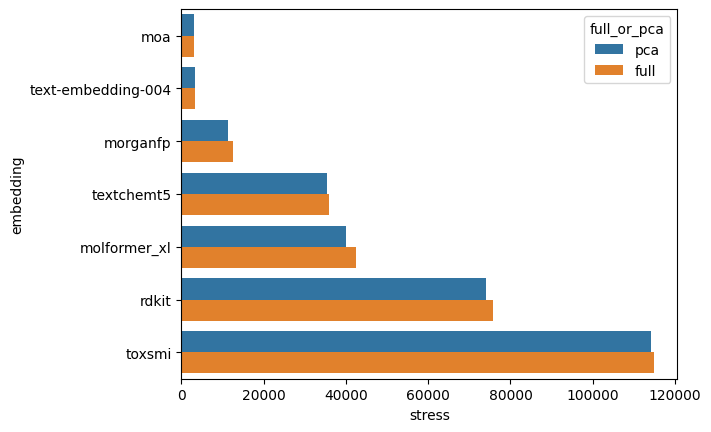

In [33]:
sns.barplot(data=res, x="stress", y="embedding", hue="full_or_pca")

<Axes: xlabel='pearson', ylabel='embedding'>

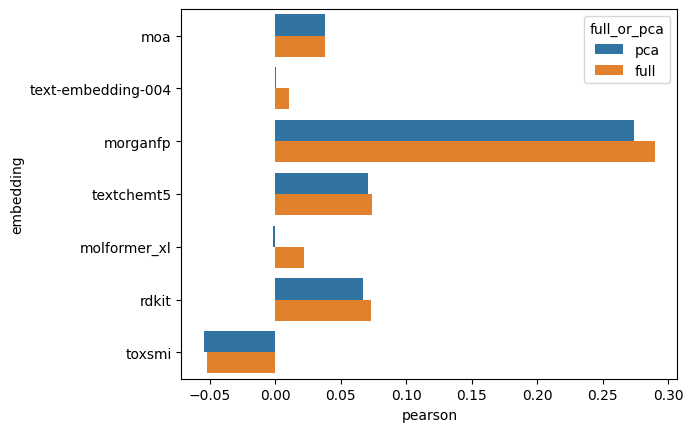

In [34]:
sns.barplot(data=res, x="pearson", y="embedding", hue="full_or_pca")

<Axes: xlabel='spearman', ylabel='embedding'>

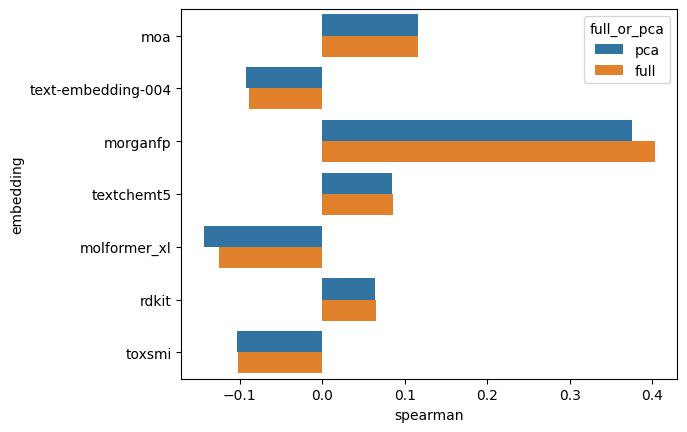

In [35]:
sns.barplot(data=res, x="spearman", y="embedding", hue="full_or_pca")

<Axes: xlabel='Fnorm', ylabel='embedding'>

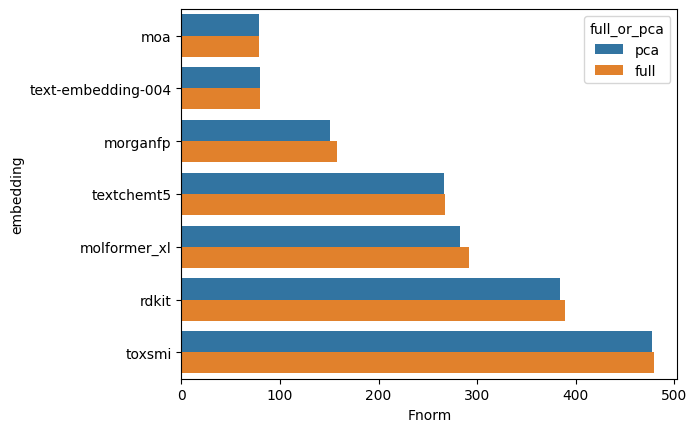

In [36]:
sns.barplot(data=res, x="Fnorm", y="embedding", hue="full_or_pca")

# Comparision to MoA embedding

In [38]:
moa_embed =  pd.read_csv(f"{base_dir}moa", index_col=0).T
moa_embed = moa_embed.loc[[i for i in moa_embed.index if i not in non_data_drugs], :]
moa_embed = moa_embed.loc[[i for i in moa_embed.index if i in smiles["Name"].values], :]
distance = euclidean_distances(moa_embed)

In [39]:
all_stresses = []
all_pearson = []
all_spearman = []
all_norms = []
for embedding in all_embeddings:
    print(embedding)
    embed =  pd.read_csv(f"{base_dir}{embedding}", index_col=0).T
    if embedding=="rdkit":
        embed.columns = embed.loc["drug", :].values
        embed = embed.loc[[i for i in embed.index if not i in ["drug", "smile"]], :]
        embed = embed.T
    embed = embed.loc[[i for i in embed.index if i not in non_data_drugs], :]
    embed = embed.loc[[i for i in embed.index if i in smiles["Name"].values], :]
    if embed.shape[1]>40:
        pca = PCA(n_components=20)
        embed = pd.DataFrame(pca.fit_transform(embed))
        
    dis = euclidean_distances(embed)
    stress = ((dis.ravel() - distance.ravel()) ** 2).sum() / 2
    pearson = pearsonr(dis.ravel(), distance.ravel()).statistic
    spearman = spearmanr(dis.ravel(), distance.ravel()).statistic
    fro_norm = np.linalg.norm(dis-distance, ord="fro")
    all_stresses.append(stress)
    all_pearson.append(pearson)
    all_spearman.append(spearman)
    all_norms.append(fro_norm)

pca_res = pd.DataFrame([all_embeddings, all_stresses, all_pearson, all_spearman, all_norms], 
                       index=["embedding", "stress", "pearson", "spearman", "Fnorm"]).T
pca_res["stress"] = pca_res["stress"].astype(float)
pca_res["full_or_pca"] = "pca"



all_stresses = []
all_pearson = []
all_spearman = []
all_norms = []
for embedding in all_embeddings:
    print(embedding)
    embed =  pd.read_csv(f"{base_dir}{embedding}", index_col=0).T
    if embedding=="rdkit":
        embed.columns = embed.loc["drug", :].values
        embed = embed.loc[[i for i in embed.index if not i in ["drug", "smile"]], :]
        embed = embed.T
    embed = embed.loc[[i for i in embed.index if i not in non_data_drugs], :]
    embed = embed.loc[[i for i in embed.index if i in smiles["Name"].values], :]
        
    dis = euclidean_distances(embed)
    stress = ((dis.ravel() - distance.ravel()) ** 2).sum() / 2
    pearson = pearsonr(dis.ravel(), distance.ravel()).statistic
    spearman = spearmanr(dis.ravel(), distance.ravel()).statistic
    fro_norm = np.linalg.norm(dis-distance, ord="fro")
    all_stresses.append(stress)
    all_pearson.append(pearson)
    all_spearman.append(spearman)
    all_norms.append(fro_norm)

full_res = pd.DataFrame([all_embeddings, all_stresses, all_pearson, all_spearman, all_norms], 
                       index=["embedding", "stress", "pearson", "spearman", "Fnorm"]).T
full_res["stress"] = full_res["stress"].astype(float)
full_res["full_or_pca"] = "full"



res=pd.concat([pca_res, full_res])

molformer_xl
morganfp
text-embedding-004
textchemt5
toxsmi
moa
rdkit
molformer_xl
morganfp
text-embedding-004
textchemt5
toxsmi
moa
rdkit


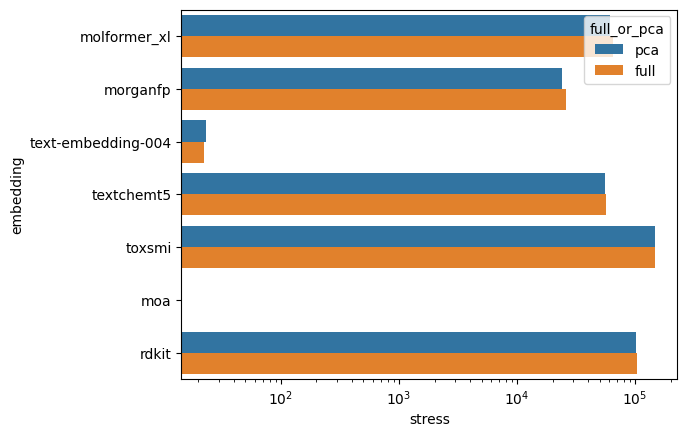

In [40]:
sns.barplot(data=res, x="stress", y="embedding", hue="full_or_pca")
plt.xscale("log")

<Axes: xlabel='pearson', ylabel='embedding'>

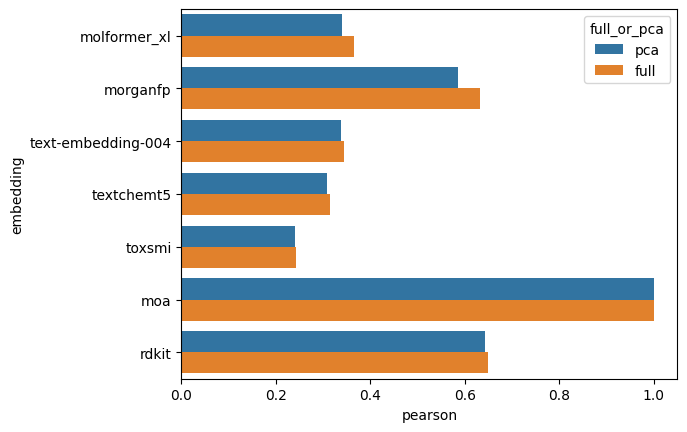

In [41]:
sns.barplot(data=res, x="pearson", y="embedding", hue="full_or_pca")

<Axes: xlabel='spearman', ylabel='embedding'>

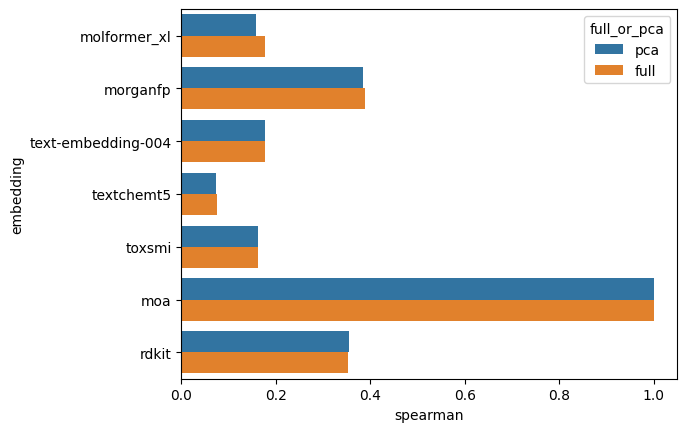

In [42]:
sns.barplot(data=res, x="spearman", y="embedding", hue="full_or_pca")

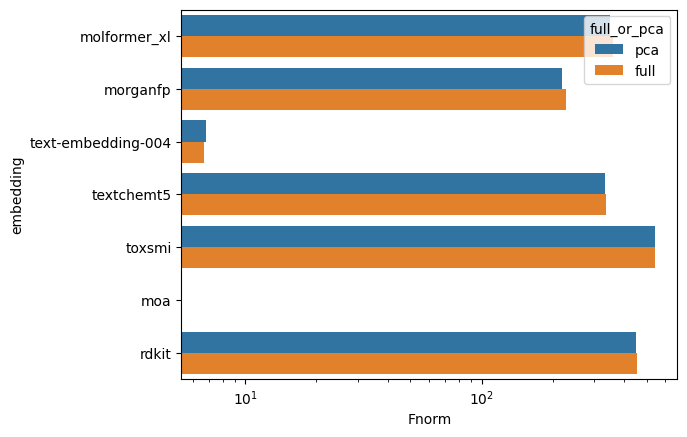

In [46]:
sns.barplot(data=res, x="Fnorm", y="embedding", hue="full_or_pca")
plt.xscale("log")